In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
np.random.seed(42)

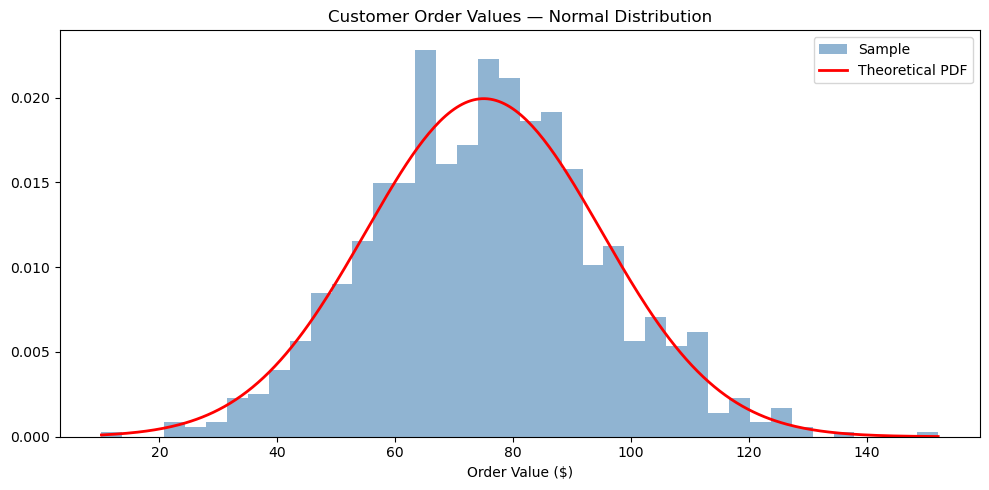

In [2]:
# Part A — Normal distribution (order values)
mu, sigma = 75, 20
order_values = np.random.normal(loc=mu, scale=sigma, size=1000)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(order_values, bins=40, density=True, alpha=0.6, color='steelblue', label='Sample')
x = np.linspace(order_values.min(), order_values.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Theoretical PDF')
ax.set_title('Customer Order Values — Normal Distribution')
ax.set_xlabel('Order Value ($)')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
#Compute business probabilities
prob_over_100 = 1 - stats.norm.cdf(100, loc=mu, scale=sigma)
print(f'P(order > $100): {prob_over_100:.4f} ({prob_over_100*100:.1f}%)')

p5 = stats.norm.ppf(0.05, loc=mu, scale=sigma)
print(f'5th percentile order value: ${p5:.2f}')

within_1sd = np.mean(np.abs(order_values - mu) < sigma)
print(f'Proportion within 1 std dev: {within_1sd:.4f} (expected ~0.6827)')

P(order > $100): 0.1056 (10.6%)
5th percentile order value: $42.10
Proportion within 1 std dev: 0.6980 (expected ~0.6827)


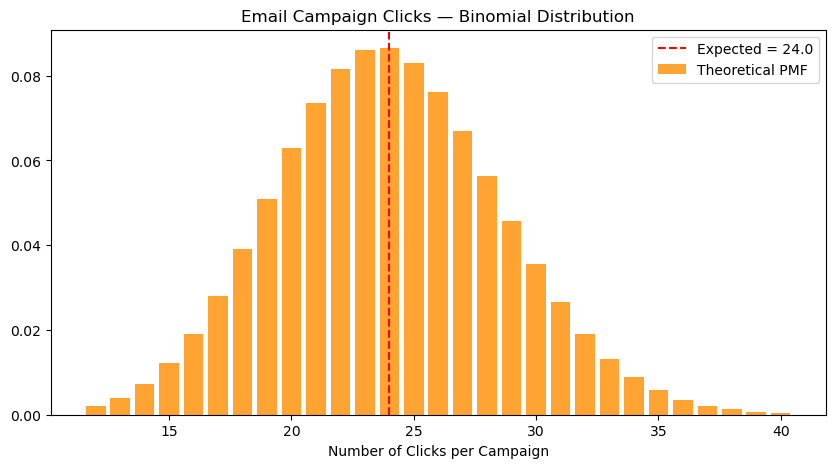

P(clicks > 30): 0.0821


In [4]:
#Part B — Binomial distribution (email clicks)
#Model click-through rates
n_emails, p_click = 200, 0.12
clicks = np.random.binomial(n=n_emails, p=p_click, size=1000)

x_vals = np.arange(clicks.min(), clicks.max()+1)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_vals, stats.binom.pmf(x_vals, n_emails, p_click),
       color='darkorange', alpha=0.8, label='Theoretical PMF')
ax.axvline(n_emails * p_click, color='red', linestyle='--', label=f'Expected = {n_emails*p_click}')
ax.set_title('Email Campaign Clicks — Binomial Distribution')
ax.set_xlabel('Number of Clicks per Campaign')
ax.legend()
plt.show()

prob_over_30 = 1 - stats.binom.cdf(30, n_emails, p_click)
print(f'P(clicks > 30): {prob_over_30:.4f}')

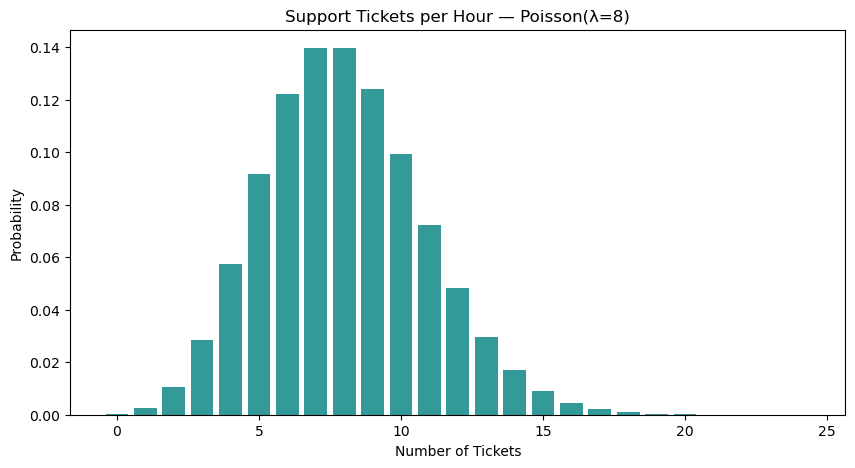

P(tickets > 12): 0.0638
Sample mean: 8.00, Sample variance: 7.86
For Poisson: mean should ≈ variance ≈ lambda (8)


In [5]:
# Part C — Poisson distribution (support tickets)
# Model rare event arrivals
lambda_rate = 8

x_pois = np.arange(0, 25)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pois, stats.poisson.pmf(x_pois, lambda_rate), color='teal', alpha=0.8)
ax.set_title(f'Support Tickets per Hour — Poisson(λ={lambda_rate})')
ax.set_xlabel('Number of Tickets')
ax.set_ylabel('Probability')
plt.show()

prob_overwhelmed = 1 - stats.poisson.cdf(12, lambda_rate)
print(f'P(tickets > 12): {prob_overwhelmed:.4f}')

samples = np.random.poisson(lam=lambda_rate, size=10000)
print(f'Sample mean: {samples.mean():.2f}, Sample variance: {samples.var():.2f}')
print(f'For Poisson: mean should ≈ variance ≈ lambda ({lambda_rate})')